# 1. Introduction

This notebook validates the temporal, spatial, and structural coverage of the City of Toronto traffic summary dataset before forecasting.

Dataset validation is a prerequisite for reliable congestion forecasting because model performance depends on whether the available observations are sufficiently representative across time, geography, and core traffic attributes. This analysis evaluates coverage depth, missingness patterns, and count-duration characteristics for the target variable `congestion_target`, defined as `avg_wkdy_pm_peak_vol`.

# 2. Dataset Overview

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

processed_path = project_root / "data" / "processed" / "traffic_summary_clean.csv"
fallback_path = project_root / "data" / "raw" / "svc_summary_data.csv"

data_path = processed_path if processed_path.exists() else fallback_path

df = pd.read_csv(data_path)

# Preserve the project definition: congestion_target = avg_wkdy_pm_peak_vol
if "congestion_target" not in df.columns and "avg_wkdy_pm_peak_vol" in df.columns:
    df["congestion_target"] = df["avg_wkdy_pm_peak_vol"]

In [2]:
print(f"Loaded data from: {data_path.relative_to(project_root)}")
print(f"Dataset shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nPreview:")
display(df.head())

Loaded data from: data/raw/svc_summary_data.csv
Dataset shape: (44470, 22)

Columns:
['_id', 'count_id', 'count_type', 'count_date_start', 'count_date_end', 'count_duration', 'location_name', 'longitude', 'latitude', 'centreline_id', 'avg_daily_vol', 'avg_weekday_daily_vol', 'avg_weekend_daily_vol', 'avg_wkdy_am_peak_start', 'avg_wkdy_am_peak_vol', 'avg_wkdy_pm_peak_start', 'avg_wkdy_pm_peak_vol', 'avg_speed', 'avg_85th_percentile_speed', 'avg_95th_percentile_speed', 'avg_heavy_pct', 'congestion_target']

Data types:


,dtype
_id,int64
count_id,int64
count_type,str
count_date_start,str
count_date_end,str
count_duration,int64
location_name,str
longitude,float64
latitude,float64
centreline_id,int64



Preview:


,_id,count_id,count_type,count_date_start,count_date_end,count_duration,location_name,longitude,latitude,centreline_id,...,avg_weekend_daily_vol,avg_wkdy_am_peak_start,avg_wkdy_am_peak_vol,avg_wkdy_pm_peak_start,avg_wkdy_pm_peak_vol,avg_speed,avg_85th_percentile_speed,avg_95th_percentile_speed,avg_heavy_pct,congestion_target
0,1,3014976,ATR_SPEED_VOLUME,2026-01-20,2026-01-22,72,Senlac Rd: Churchill Ave - Horsham Ave,-79.427870,43.770960,438812,...,NaN,08:15:00,638.0,16:15:00,747.0,37.3,43.9,48.5,NaN,747.0
1,2,3015033,ATR_SPEED_VOLUME,2026-01-20,2026-01-22,72,Beachell St: Eglinton Ave E - Luella St,-79.222513,43.743367,110508,...,NaN,08:00:00,71.0,16:15:00,80.0,31.0,39.8,44.6,NaN,80.0
2,3,3015251,ATR_SPEED_VOLUME,2026-01-20,2026-01-22,72,Brookshire Blvd: Lanewood Cres - Blairwood Ter,-79.325944,43.803354,104810,...,NaN,08:15:00,45.0,18:00:00,30.0,29.3,38.4,44.0,NaN,30.0
3,4,3015035,ATR_SPEED_VOLUME,2026-01-20,2026-01-22,72,Dufferin St: Wenderly Dr - Claver Ave,-79.454170,43.711550,9655343,...,NaN,08:00:00,2186.0,16:45:00,2070.0,40.4,51.5,57.2,NaN,2070.0
4,5,3015036,ATR_SPEED_VOLUME,2026-01-20,2026-01-22,72,Bremner Blvd: Olympic Park Trl - Rees St,-79.386180,43.641902,30106817,...,NaN,08:30:00,490.0,17:00:00,548.0,29.9,38.4,43.8,NaN,548.0


The dataset contains traffic count records with temporal fields, location identifiers, geospatial coordinates, and traffic summary metrics. The target variable used for congestion forecasting remains `avg_wkdy_pm_peak_vol` (stored as `congestion_target` in this notebook for clarity and consistency).

# 3. Temporal Coverage Analysis

Temporal range (count_date_start): 1993 to 2026

Observations per year:


,observations
year,
1993.0,1836
1994.0,1062
1995.0,992
1996.0,1324
1997.0,321
1998.0,1294
1999.0,1406
2000.0,569
2001.0,1527


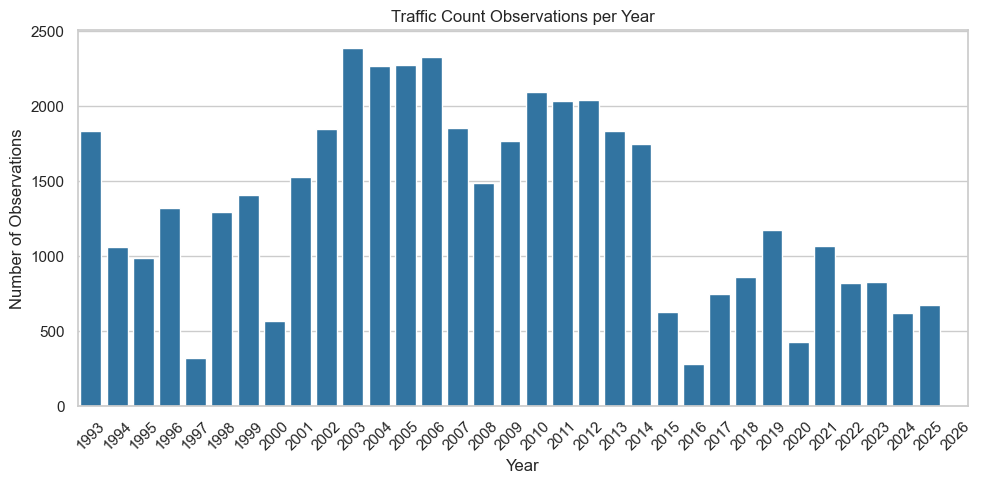

In [3]:
df["count_date_start"] = pd.to_datetime(df["count_date_start"], errors="coerce")

valid_date_mask = df["count_date_start"].notna()
df.loc[valid_date_mask, "year"] = df.loc[valid_date_mask, "count_date_start"].dt.year

df.loc[valid_date_mask, "month"] = df.loc[valid_date_mask, "count_date_start"].dt.month

year_min = int(df.loc[valid_date_mask, "year"].min())
year_max = int(df.loc[valid_date_mask, "year"].max())

yearly_obs = (
    df.loc[valid_date_mask]
    .groupby("year")
    .size()
    .sort_index()
    .astype("int64")
)

print(f"Temporal range (count_date_start): {year_min} to {year_max}")
print("\nObservations per year:")
display(yearly_obs.to_frame("observations"))

plt.figure(figsize=(10, 5))
sns.barplot(x=yearly_obs.index.astype(int), y=yearly_obs.values, color="#1f77b4")
plt.title("Traffic Count Observations per Year")
plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The time span indicates whether the dataset is adequate for learning recurring seasonal and yearly congestion behavior. Uneven yearly volumes or sparse years should be treated as potential coverage gaps because they can reduce temporal generalizability and bias model training toward periods with heavier data collection.

# 4. Spatial Coverage Analysis

Unique traffic count locations: 14109

Unique locations per year:


,unique_locations
year,
1993.0,1568
1994.0,933
1995.0,665
1996.0,1145
1997.0,130
1998.0,245
1999.0,134
2000.0,473
2001.0,1207


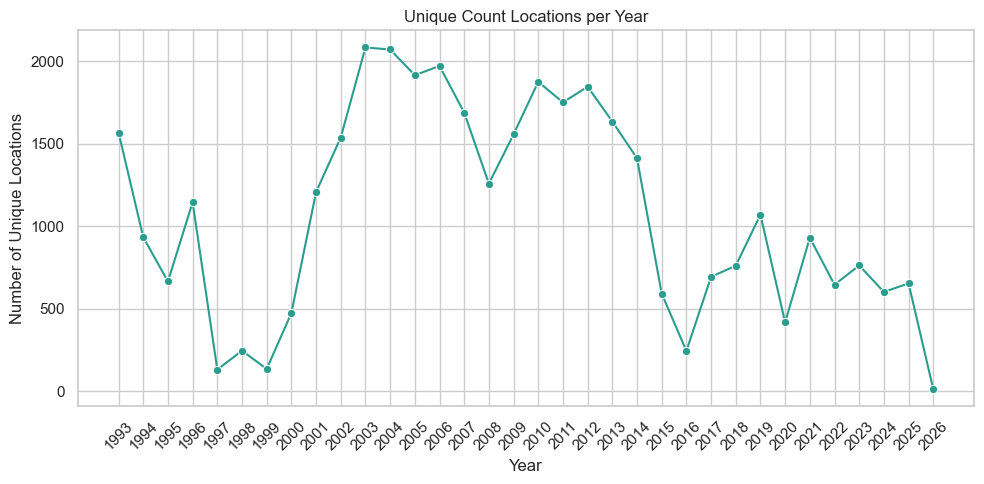

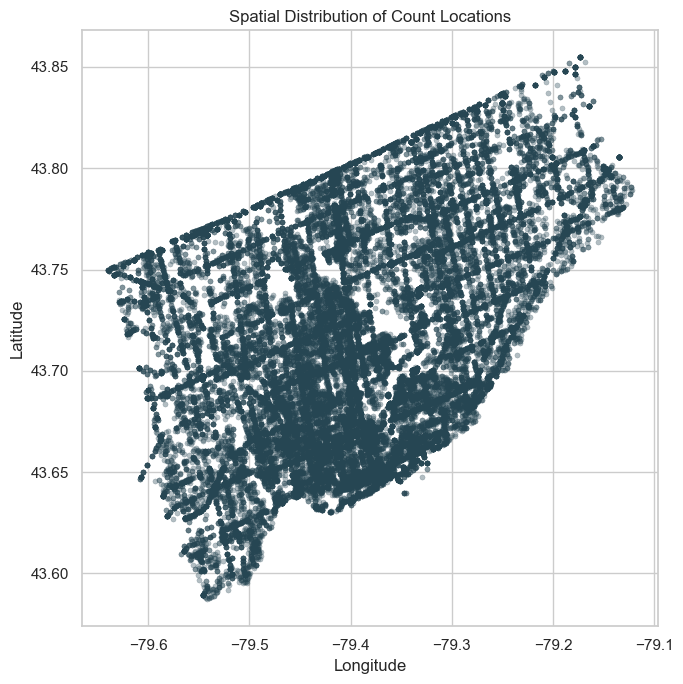

In [4]:
unique_locations = df["location_name"].nunique(dropna=True)

locations_per_year = (
    df.loc[df["year"].notna()]
    .groupby("year")["location_name"]
    .nunique()
    .sort_index()
    .astype("int64")
)

print(f"Unique traffic count locations: {unique_locations}")
print("\nUnique locations per year:")
display(locations_per_year.to_frame("unique_locations"))

plt.figure(figsize=(10, 5))
sns.lineplot(x=locations_per_year.index.astype(int), y=locations_per_year.values, marker="o", color="#2a9d8f")
plt.title("Unique Count Locations per Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique Locations")
plt.xticks(locations_per_year.index.astype(int), rotation=45)
plt.tight_layout()
plt.show()

if {"latitude", "longitude"}.issubset(df.columns):
    geo_df = df[["latitude", "longitude"]].dropna()
    plt.figure(figsize=(7, 7))
    sns.scatterplot(data=geo_df, x="longitude", y="latitude", s=14, alpha=0.35, color="#264653", edgecolor=None)
    plt.title("Spatial Distribution of Count Locations")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()

Spatial coverage should be interpreted in terms of both the total number of monitored locations and yearly consistency of location sampling. Concentration in certain corridors or inconsistent location reuse across years may limit the model’s ability to generalize city-wide traffic congestion dynamics.

# 5. Data Completeness and Missing Values

In [5]:
missing_counts = df.isna().sum().sort_values(ascending=False)
print("Missing value counts by column:")
display(missing_counts.to_frame("missing_count"))

key_fields = ["avg_daily_vol", "avg_wkdy_pm_peak_vol", "avg_speed", "avg_heavy_pct"]
missing_pct = (df[key_fields].isna().mean() * 100).sort_values(ascending=False)
print("\nMissing percentage for key forecasting fields (%):")
display(missing_pct.to_frame("missing_pct").round(2))

Missing value counts by column:


,missing_count
avg_heavy_pct,44103
avg_weekend_daily_vol,40329
avg_95th_percentile_speed,28361
avg_85th_percentile_speed,28361
avg_speed,28361
avg_wkdy_am_peak_start,1037
avg_wkdy_am_peak_vol,1037
congestion_target,1036
avg_wkdy_pm_peak_vol,1036
avg_wkdy_pm_peak_start,1036



Missing percentage for key forecasting fields (%):


,missing_pct
avg_heavy_pct,99.17
avg_speed,63.78
avg_wkdy_pm_peak_vol,2.33
avg_daily_vol,0.00


Missingness in core traffic intensity and speed fields directly affects feature reliability and may reduce usable training data. If missingness is concentrated in specific periods or locations, it can introduce systematic bias rather than random noise, weakening forecasting validity.

# 6. Count Duration Analysis

Count duration summary (hours):


,count_duration
count,44470.000000
mean,62.185743
std,73.031151
min,24.000000
25%,24.000000
50%,72.000000
75%,72.000000
max,7632.000000


Share within expected 24-168 hour range: 98.64%
Share below 24 hours: 0.00%
Share above 168 hours: 1.36%


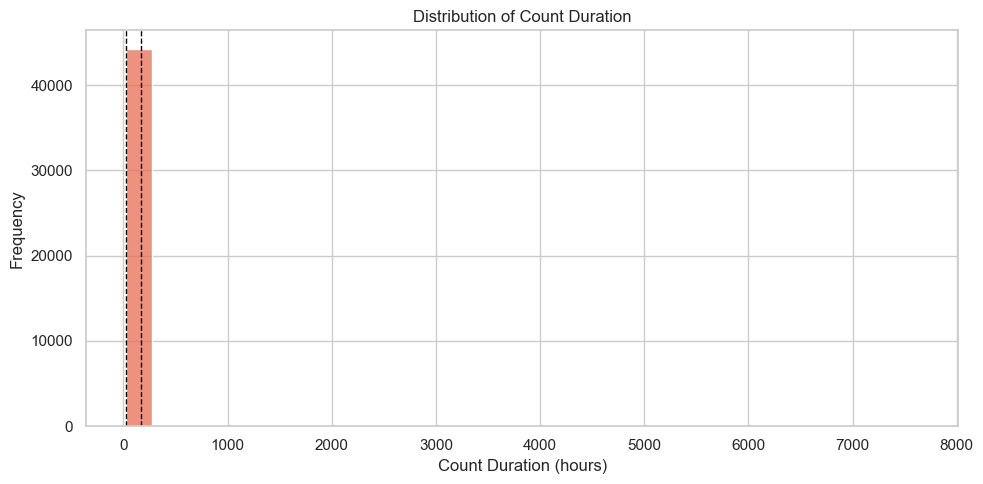

In [6]:
duration_summary = df["count_duration"].describe()
within_expected_pct = df["count_duration"].between(24, 168, inclusive="both").mean() * 100
below_expected_pct = (df["count_duration"] < 24).mean() * 100
above_expected_pct = (df["count_duration"] > 168).mean() * 100

print("Count duration summary (hours):")
display(duration_summary.to_frame("count_duration"))

print(f"Share within expected 24-168 hour range: {within_expected_pct:.2f}%")
print(f"Share below 24 hours: {below_expected_pct:.2f}%")
print(f"Share above 168 hours: {above_expected_pct:.2f}%")

plt.figure(figsize=(10, 5))
sns.histplot(data=df.dropna(subset=["count_duration"]), x="count_duration", bins=30, color="#e76f51", edgecolor="white")
plt.axvline(24, color="black", linestyle="--", linewidth=1)
plt.axvline(168, color="black", linestyle="--", linewidth=1)
plt.title("Distribution of Count Duration")
plt.xlabel("Count Duration (hours)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

A high proportion of durations within 24 to 168 hours suggests alignment with standard short monitoring windows used in traffic programs. Large proportions of shorter ad-hoc counts may increase volatility and reduce consistency for forecasting applications that assume comparable observation windows.

# 7. Data Suitability Assessment

**Temporal coverage adequacy:** The dataset spans multiple years, enabling evaluation of broad congestion patterns, but yearly volume imbalances should be considered during model development.

**Spatial coverage adequacy:** The dataset includes many unique Toronto locations, supporting corridor-level analysis, while potential concentration in selected road segments may limit full urban representativeness.

**Data quality level:** Core traffic fields are present and structured for analysis, with missingness diagnostics indicating where preprocessing or imputation may be necessary.

**Identified limitations:** Observations are count-based rather than continuous sensor streams, and coverage consistency depends on annual survey deployment patterns.

**Final conclusion:** The dataset is suitable for congestion forecasting at a city traffic-count level, provided that downstream modeling explicitly addresses temporal imbalance, spatial sampling variation, missing values, and count-duration heterogeneity.

# 8. Limitations Section

- **Ad-hoc data collection:** Counts are collected through periodic programs and are not uniformly scheduled across all locations and years.
- **Non-continuous monitoring:** The dataset does not represent uninterrupted time-series monitoring for each road segment.
- **Geographic boundary limitation (Toronto only):** Findings and resulting models are not directly generalizable beyond the City of Toronto.
- **Potential anomalies in count data:** Measurement artifacts, atypical events, and short-duration counts may introduce outliers or non-representative observations.